# 03 – Datenpipeline

**Projekt:** Polymarket Reddit Sentiment  
**Kurs:** Data Wrangling & Engineering (FHNW)

Dieses Notebook dokumentiert die vollständige Datenpipeline vom Rohdaten-Abruf bis zum analysierbaren Datensatz.

```
┌──────────────┐    ┌──────────────┐    ┌──────────────┐    ┌──────────────┐
│   INGEST     │───▶│   CLEAN      │───▶│  TRANSFORM   │───▶│   OUTPUT     │
│              │    │              │    │              │    │              │
│ Reddit API   │    │ Missing vals │    │ Sentiment    │    │ CSV / DF     │
│ Polymarket   │    │ Duplikate    │    │ Aggregation  │    │ Dashboard    │
│              │    │ Outlier      │    │ Join         │    │              │
└──────────────┘    └──────────────┘    └──────────────┘    └──────────────┘
```

---

In [1]:
import sys
sys.path.insert(0, '..')

import re
import os
import pandas as pd
import numpy as np
from scipy import stats
from dataclasses import dataclass, field
from typing import Optional
import warnings
warnings.filterwarnings('ignore')

from src import reddit, polymarket, sentiment

print('Libraries geladen.')

Libraries geladen.


## 1. Pipeline-Konfiguration

In [2]:
@dataclass
class PipelineConfig:
    """Konfiguration der Datenpipeline."""
    query: str = 'Bitcoin'
    subreddits: list = field(default_factory=lambda: ['investing', 'stocks', 'worldnews', 'CryptoCurrency'])
    post_limit: int = 100
    winsorize_lower: float = 0.05
    winsorize_upper: float = 0.95
    min_title_length: int = 5
    output_dir: str = '../data'

config = PipelineConfig(query='Bitcoin')
print(config)

PipelineConfig(query='Bitcoin', subreddits=['investing', 'stocks', 'worldnews', 'CryptoCurrency'], post_limit=100, winsorize_lower=0.05, winsorize_upper=0.95, min_title_length=5, output_dir='../data')


## 2. Pipeline-Klasse

In [3]:
class SentimentPipeline:
    """
    Vollständige Datenpipeline:
      1. Ingest  – Daten von Reddit + Polymarket abrufen
      2. Clean   – Fehlende Werte, Duplikate, Ausreisser behandeln
      3. Transform – Sentiment berechnen, Daten zusammenführen
      4. Output  – Ergebnisse speichern
    """

    def __init__(self, config: PipelineConfig):
        self.config = config
        self.log = []

    def _log(self, step: str, msg: str):
        entry = f'[{step}] {msg}'
        self.log.append(entry)
        print(entry)

    # ── Schritt 1: Ingest ────────────────────────────────────────────────────
    def ingest(self) -> tuple[pd.DataFrame, pd.DataFrame]:
        self._log('INGEST', f'Lade Reddit-Posts für "{self.config.query}"...')
        raw_posts = reddit.get_posts(
            self.config.query,
            self.config.subreddits,
            self.config.post_limit
        )
        self._log('INGEST', f'{len(raw_posts)} Posts geladen')

        self._log('INGEST', 'Lade Polymarket-Daten...')
        try:
            markets = polymarket.get_markets(limit=50)
            self._log('INGEST', f'{len(markets)} Märkte geladen')
        except Exception as e:
            self._log('INGEST', f'Polymarket nicht erreichbar: {e} – verwende leeren DataFrame')
            markets = pd.DataFrame(columns=['id', 'question', 'probability', 'category', 'volume'])

        return raw_posts, markets

    # ── Schritt 2: Clean ────────────────────────────────────────────────────
    def clean(self, posts: pd.DataFrame, markets: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
        posts = posts.copy()
        markets = markets.copy()

        # Fehlende Werte
        posts['text'] = posts['text'].fillna('')
        self._log('CLEAN', f'text: fehlende Werte mit "" gefüllt')

        if 'probability' in markets.columns and markets['probability'].isnull().any():
            markets['probability_missing'] = markets['probability'].isnull().astype(int)
            markets['probability'] = markets['probability'].fillna(markets['probability'].median())
            self._log('CLEAN', 'probability: Median-Imputation + Indikatorvariable')

        if 'category' in markets.columns:
            markets['category'] = markets['category'].fillna('Unknown')

        # Duplikate
        n_before = len(posts)
        posts = posts.drop_duplicates(subset='id', keep='first')
        posts = posts.drop_duplicates(subset='title', keep='first')
        self._log('CLEAN', f'Duplikate entfernt: {n_before - len(posts)}')

        # Ausreisser (Winsorisierung)
        for col in ['score', 'num_comments']:
            if col in posts.columns:
                lo = posts[col].quantile(self.config.winsorize_lower)
                hi = posts[col].quantile(self.config.winsorize_upper)
                posts[col] = posts[col].clip(lower=lo, upper=hi)
                self._log('CLEAN', f'{col}: Winsorisiert [{lo:.0f}, {hi:.0f}]')

        # Textreinigung
        def clean_text(t):
            if not isinstance(t, str):
                return ''
            t = re.sub(r'http\S+', '', t)
            t = re.sub(r'\[deleted\]|\[removed\]', '', t)
            return re.sub(r'\s+', ' ', t).strip()

        posts['title_clean'] = posts['title'].apply(clean_text)
        posts['text_clean']  = posts['text'].apply(clean_text)

        # Leere Posts markieren
        posts['is_empty_content'] = (
            (posts['title_clean'].str.len() < self.config.min_title_length) &
            (posts['text_clean'].str.len() < self.config.min_title_length)
        ).astype(int)
        self._log('CLEAN', f'Leere Posts markiert: {posts["is_empty_content"].sum()}')

        return posts, markets

    # ── Schritt 3: Transform ────────────────────────────────────────────────
    def transform(self, posts: pd.DataFrame, markets: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
        # Sentiment berechnen
        posts = sentiment.analyze(posts)
        self._log('TRANSFORM', f'Sentiment berechnet für {len(posts)} Posts')

        # Datum normalisieren
        if 'created_utc' in posts.columns:
            posts['date'] = pd.to_datetime(posts['created_utc']).dt.date

        # Tages-Aggregat
        if 'date' in posts.columns:
            daily = posts.groupby('date').agg(
                mean_compound=('compound', 'mean'),
                post_count=('id', 'count'),
                positive_pct=('sentiment_label', lambda x: (x == 'positive').mean())
            ).reset_index()
            self._log('TRANSFORM', f'Tages-Aggregat erstellt: {len(daily)} Tage')
        else:
            daily = pd.DataFrame()

        return posts, daily

    # ── Schritt 4: Output ───────────────────────────────────────────────────
    def save(self, posts: pd.DataFrame, daily: pd.DataFrame):
        os.makedirs(self.config.output_dir, exist_ok=True)
        posts.to_csv(f'{self.config.output_dir}/reddit_clean.csv', index=False)
        if not daily.empty:
            daily.to_csv(f'{self.config.output_dir}/daily_sentiment.csv', index=False)
        self._log('OUTPUT', f'Gespeichert in {self.config.output_dir}/')

    # ── Vollständige Pipeline ───────────────────────────────────────────────
    def run(self) -> tuple[pd.DataFrame, pd.DataFrame]:
        print('=' * 50)
        print(f'Pipeline Start: "{self.config.query}"')
        print('=' * 50)

        raw_posts, markets = self.ingest()
        clean_posts, clean_markets = self.clean(raw_posts, markets)
        final_posts, daily = self.transform(clean_posts, clean_markets)
        self.save(final_posts, daily)

        print('=' * 50)
        print(f'Pipeline abgeschlossen. {len(final_posts)} Posts verarbeitet.')
        print('=' * 50)
        return final_posts, daily

print('Pipeline-Klasse definiert.')

Pipeline-Klasse definiert.


## 3. Pipeline ausführen

In [4]:
pipeline = SentimentPipeline(config)
posts_final, daily_df = pipeline.run()

Pipeline Start: "Bitcoin"
[INGEST] Lade Reddit-Posts für "Bitcoin"...
[INGEST] 100 Posts geladen
[INGEST] Lade Polymarket-Daten...
[INGEST] Polymarket nicht erreichbar: Polymarket API nicht erreichbar: HTTPSConnectionPool(host='clob.polymarket.com', port=443): Max retries exceeded with url: /markets?limit=50&active=true&closed=false&archived=false (Caused by NameResolutionError("HTTPSConnection(host='clob.polymarket.com', port=443): Failed to resolve 'clob.polymarket.com' ([Errno 11001] getaddrinfo failed)")) – verwende leeren DataFrame
[CLEAN] text: fehlende Werte mit "" gefüllt
[CLEAN] Duplikate entfernt: 0
[CLEAN] score: Winsorisiert [0, 566]
[CLEAN] num_comments: Winsorisiert [1, 112]
[CLEAN] Leere Posts markiert: 0
[TRANSFORM] Sentiment berechnet für 100 Posts
[TRANSFORM] Tages-Aggregat erstellt: 13 Tage
[OUTPUT] Gespeichert in ../data/
Pipeline abgeschlossen. 100 Posts verarbeitet.


## 4. Pipeline-Log anzeigen

In [5]:
print('\nPipeline-Log:')
for entry in pipeline.log:
    print(f'  {entry}')


Pipeline-Log:
  [INGEST] Lade Reddit-Posts für "Bitcoin"...
  [INGEST] 100 Posts geladen
  [INGEST] Lade Polymarket-Daten...
  [INGEST] Polymarket nicht erreichbar: Polymarket API nicht erreichbar: HTTPSConnectionPool(host='clob.polymarket.com', port=443): Max retries exceeded with url: /markets?limit=50&active=true&closed=false&archived=false (Caused by NameResolutionError("HTTPSConnection(host='clob.polymarket.com', port=443): Failed to resolve 'clob.polymarket.com' ([Errno 11001] getaddrinfo failed)")) – verwende leeren DataFrame
  [CLEAN] text: fehlende Werte mit "" gefüllt
  [CLEAN] Duplikate entfernt: 0
  [CLEAN] score: Winsorisiert [0, 566]
  [CLEAN] num_comments: Winsorisiert [1, 112]
  [CLEAN] Leere Posts markiert: 0
  [TRANSFORM] Sentiment berechnet für 100 Posts
  [TRANSFORM] Tages-Aggregat erstellt: 13 Tage
  [OUTPUT] Gespeichert in ../data/


## 5. Ergebnis-Überblick

In [6]:
print(f'Output-Shape: {posts_final.shape}')
print(f'Spalten:      {list(posts_final.columns)}')
print()
posts_final.head(3)

Output-Shape: (100, 14)
Spalten:      ['id', 'title', 'text', 'subreddit', 'score', 'num_comments', 'created_utc', 'url', 'title_clean', 'text_clean', 'is_empty_content', 'compound', 'sentiment_label', 'date']



,id,title,text,subreddit,score,num_comments,created_utc,url,title_clean,text_clean,is_empty_content,compound,sentiment_label,date
0,1rjr1a8,Bitfinex Revives Tokenized Bond Program on Bit...,,CryptoCurrency,0.0,1.0,2026-03-03 14:40:01+00:00,https://reddit.com/r/CryptoCurrency/comments/1...,Bitfinex Revives Tokenized Bond Program on Bit...,,0,0.3818,positive,2026-03-03
1,1rjqgor,Strive strategist says AI deflation could push...,,CryptoCurrency,9.0,28.0,2026-03-03 14:16:50+00:00,https://reddit.com/r/CryptoCurrency/comments/1...,Strive strategist says AI deflation could push...,,0,0.0000,neutral,2026-03-03
2,1rjphui,"MARA Holdings Begins Selling Bitcoin, Holds 53...",,CryptoCurrency,48.0,17.0,2026-03-03 13:35:26+00:00,https://reddit.com/r/CryptoCurrency/comments/1...,"MARA Holdings Begins Selling Bitcoin, Holds 53...",,0,0.2023,positive,2026-03-03


In [7]:
if not daily_df.empty:
    print('Tages-Aggregat (daily_sentiment):')
    print(daily_df.to_string(index=False))

Tages-Aggregat (daily_sentiment):
      date  mean_compound  post_count  positive_pct
2026-02-19      -0.993800           1      0.000000
2026-02-20       0.182490          10      0.500000
2026-02-21      -0.012780          10      0.400000
2026-02-22       0.032517           6      0.500000
2026-02-23      -0.246725           8      0.125000
2026-02-24       0.039000          10      0.300000
2026-02-25       0.300456           9      0.444444
2026-02-26       0.000378           9      0.333333
2026-02-27       0.318420           5      0.600000
2026-02-28      -0.092814           7      0.428571
2026-03-01       0.000057           7      0.285714
2026-03-02       0.260179          14      0.500000
2026-03-03       0.323425           4      0.750000


## 6. Pipeline – Verschiedene Themen vergleichen

In [8]:
topics = ['Bitcoin', 'Trump', 'Climate Change']
results = {}

for topic in topics:
    cfg = PipelineConfig(query=topic, post_limit=50)
    pipe = SentimentPipeline(cfg)
    try:
        df, _ = pipe.run()
        agg = sentiment.aggregate(df)
        results[topic] = agg
        print(f'{topic}: mean={agg["mean_compound"]:+.3f}, label={agg["label"]}')
    except Exception as e:
        print(f'{topic}: Fehler – {e}')

Pipeline Start: "Bitcoin"
[INGEST] Lade Reddit-Posts für "Bitcoin"...
[INGEST] 50 Posts geladen
[INGEST] Lade Polymarket-Daten...
[INGEST] Polymarket nicht erreichbar: Polymarket API nicht erreichbar: HTTPSConnectionPool(host='clob.polymarket.com', port=443): Max retries exceeded with url: /markets?limit=50&active=true&closed=false&archived=false (Caused by NameResolutionError("HTTPSConnection(host='clob.polymarket.com', port=443): Failed to resolve 'clob.polymarket.com' ([Errno 11001] getaddrinfo failed)")) – verwende leeren DataFrame
[CLEAN] text: fehlende Werte mit "" gefüllt
[CLEAN] Duplikate entfernt: 0
[CLEAN] score: Winsorisiert [0, 501]
[CLEAN] num_comments: Winsorisiert [1, 91]
[CLEAN] Leere Posts markiert: 0
[TRANSFORM] Sentiment berechnet für 50 Posts
[TRANSFORM] Tages-Aggregat erstellt: 7 Tage
[OUTPUT] Gespeichert in ../data/
Pipeline abgeschlossen. 50 Posts verarbeitet.
Bitcoin: mean=+0.150, label=positive
Pipeline Start: "Trump"
[INGEST] Lade Reddit-Posts für "Trump"...
[

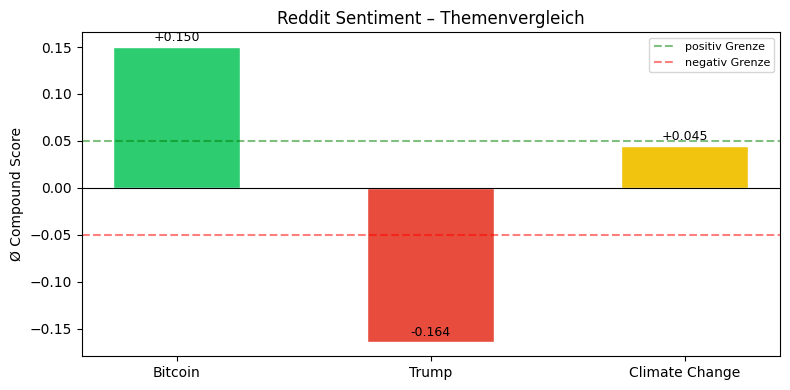

In [9]:
import matplotlib.pyplot as plt

if results:
    topics_list = list(results.keys())
    scores = [results[t]['mean_compound'] for t in topics_list]
    colors = ['#2ecc71' if s >= 0.05 else '#e74c3c' if s <= -0.05 else '#f1c40f' for s in scores]

    fig, ax = plt.subplots(figsize=(8, 4))
    bars = ax.bar(topics_list, scores, color=colors, edgecolor='white', width=0.5)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.axhline(0.05, color='green', linestyle='--', alpha=0.5, label='positiv Grenze')
    ax.axhline(-0.05, color='red', linestyle='--', alpha=0.5, label='negativ Grenze')
    ax.set_ylabel('Ø Compound Score')
    ax.set_title('Reddit Sentiment – Themenvergleich')
    ax.legend(fontsize=8)
    for bar, score in zip(bars, scores):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f'{score:+.3f}', ha='center', va='bottom', fontsize=9)
    plt.tight_layout()
    plt.savefig('../notebooks/pipeline_themenvergleich.png', dpi=120, bbox_inches='tight')
    plt.show()